In [24]:
import os

DIR_PATH = '/home/fedosdan2/Study/TCP/sem_1_titatnic/titanic'
TRAIN_PATH = os.path.join(DIR_PATH, 'train.csv')

import pandas as pd

df_train = pd.read_csv(TRAIN_PATH)

# Размерность данных
print(f'Размер датасета: {df_train.shape}')
print(f'Количество строк: {df_train.shape[0]}')
print(f'Количество столбцов: {df_train.shape[1]}')
df_train.head(5)


Размер датасета: (891, 12)
Количество строк: 891
Количество столбцов: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Analyze of data

In [25]:
# Краткая информация о типах данных и пропусках
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### Missing values

Количество пропусков в каждом столбце:
Age         177
Cabin       687
Embarked      2
dtype: int64


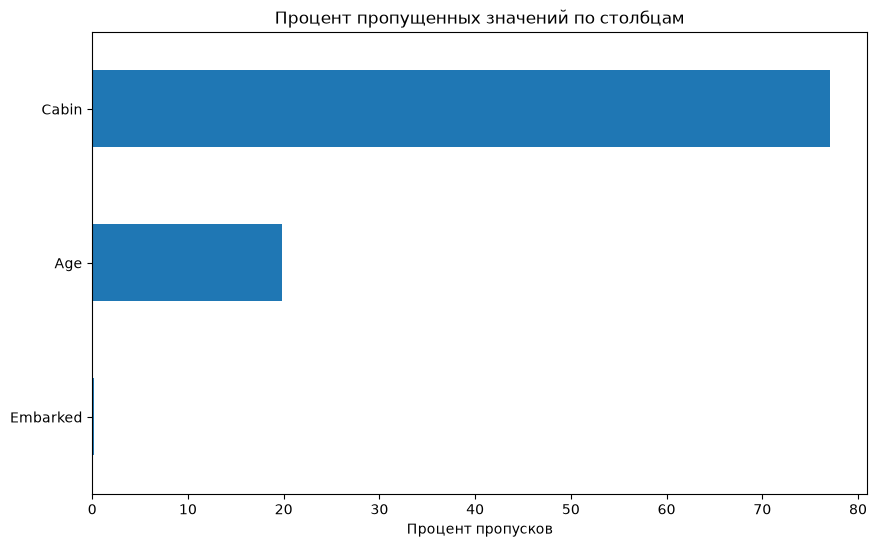

In [26]:
# Абсолютное количество пропусков
missing_count = df_train.isnull().sum()
print('Количество пропусков в каждом столбце:')
print(missing_count[missing_count > 0])


import matplotlib.pyplot as plt

missing_percent = df_train.isnull().mean() * 100
# Визуализация пропусков
plt.figure(figsize=(10, 6))
missing_percent[missing_percent > 0].sort_values().plot(kind='barh')
plt.title('Процент пропущенных значений по столбцам')
plt.xlabel('Процент пропусков')
plt.show()

## Types

In [27]:
# Типы данных каждого столбца
print('Типы данных:')
print(df_train.dtypes)

# Количество уникальных значений в каждом столбце
print('\nКоличество уникальных значений:')
print(df_train.nunique())

Типы данных:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Количество уникальных значений:
PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64


Категориальные признаки: ['Cabin', 'Embarked', 'Sex', 'Survived', 'Pclass', 'Name', 'Ticket']


/tmp/ipykernel_270742/3220435961.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_train.select_dtypes(include=['object', 'category']).columns.tolist()


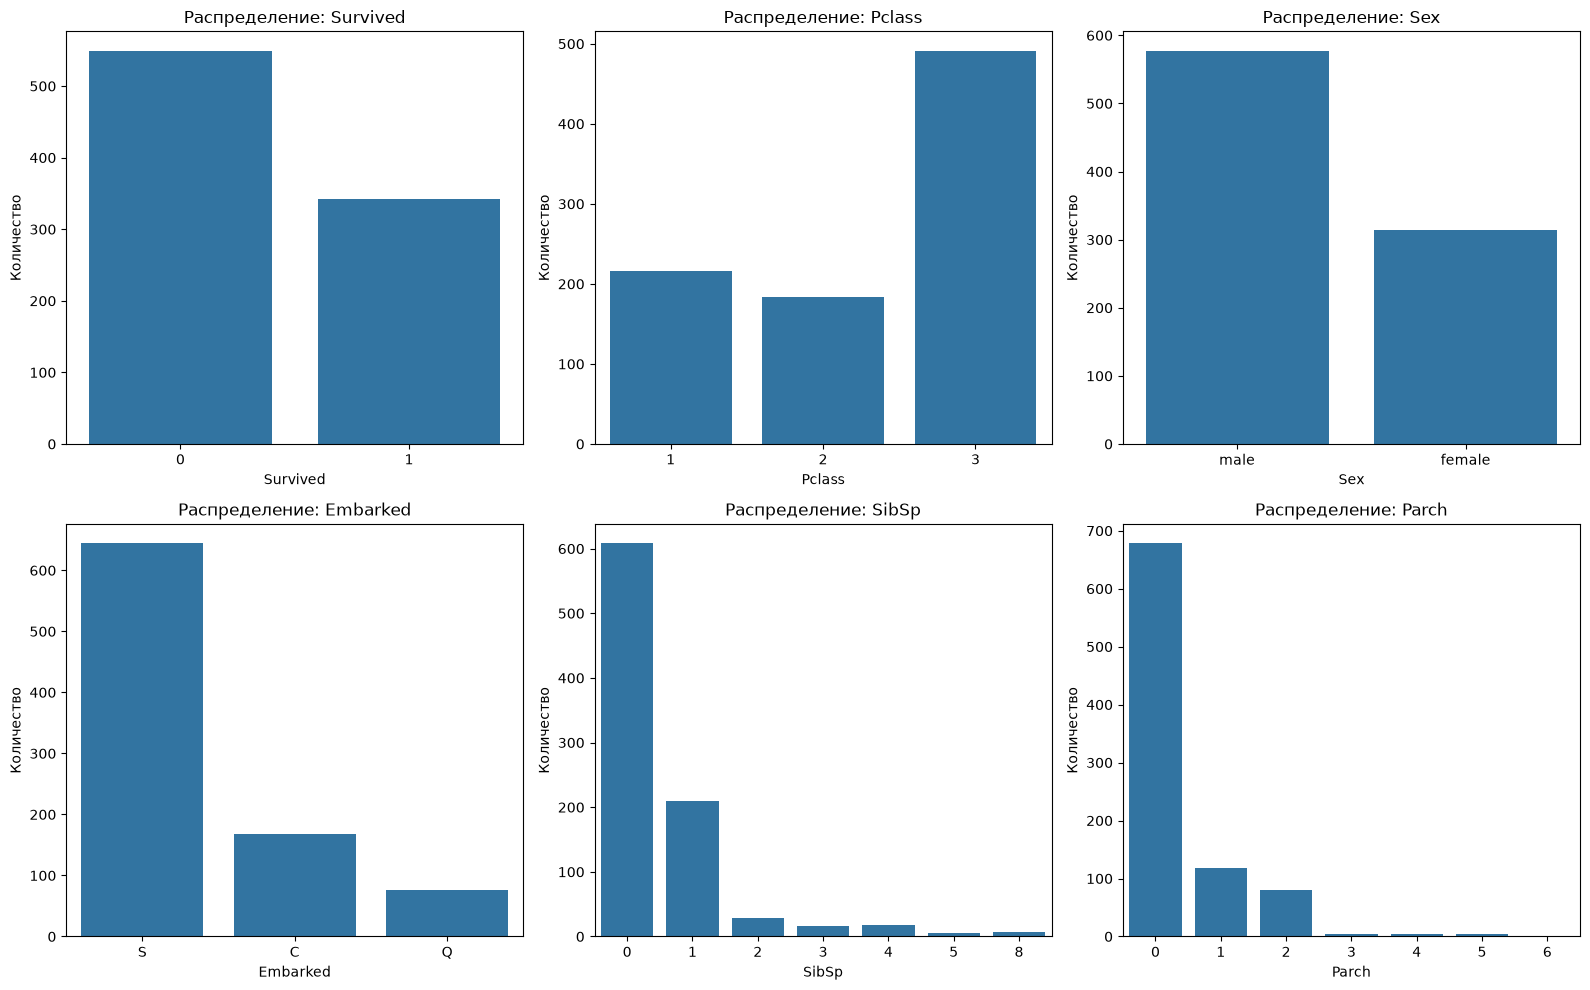

In [28]:
import seaborn as sns

# Определяем категориальные столбцы
categorical_cols = df_train.select_dtypes(include=['object', 'category']).columns.tolist()
# Добавим также Pclass, так как он по сути категориальный (хотя числовой)
categorical_cols.append('Pclass')
categorical_cols.append('Survived')  # целевая переменная тоже категориальная
categorical_cols = list(set(categorical_cols))
print('Категориальные признаки:', categorical_cols)

# Визуализация распределений категориальных признаков
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(['Survived', 'Pclass', 'Sex', 'Embarked', 'SibSp', 'Parch']):
    sns.countplot(x=col, data=df_train, ax=axes[i])
    axes[i].set_title(f'Распределение: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Количество')

plt.tight_layout()
plt.show()

Числовые признаки: ['Age', 'SibSp', 'Parch', 'Fare'] , Количество:  4


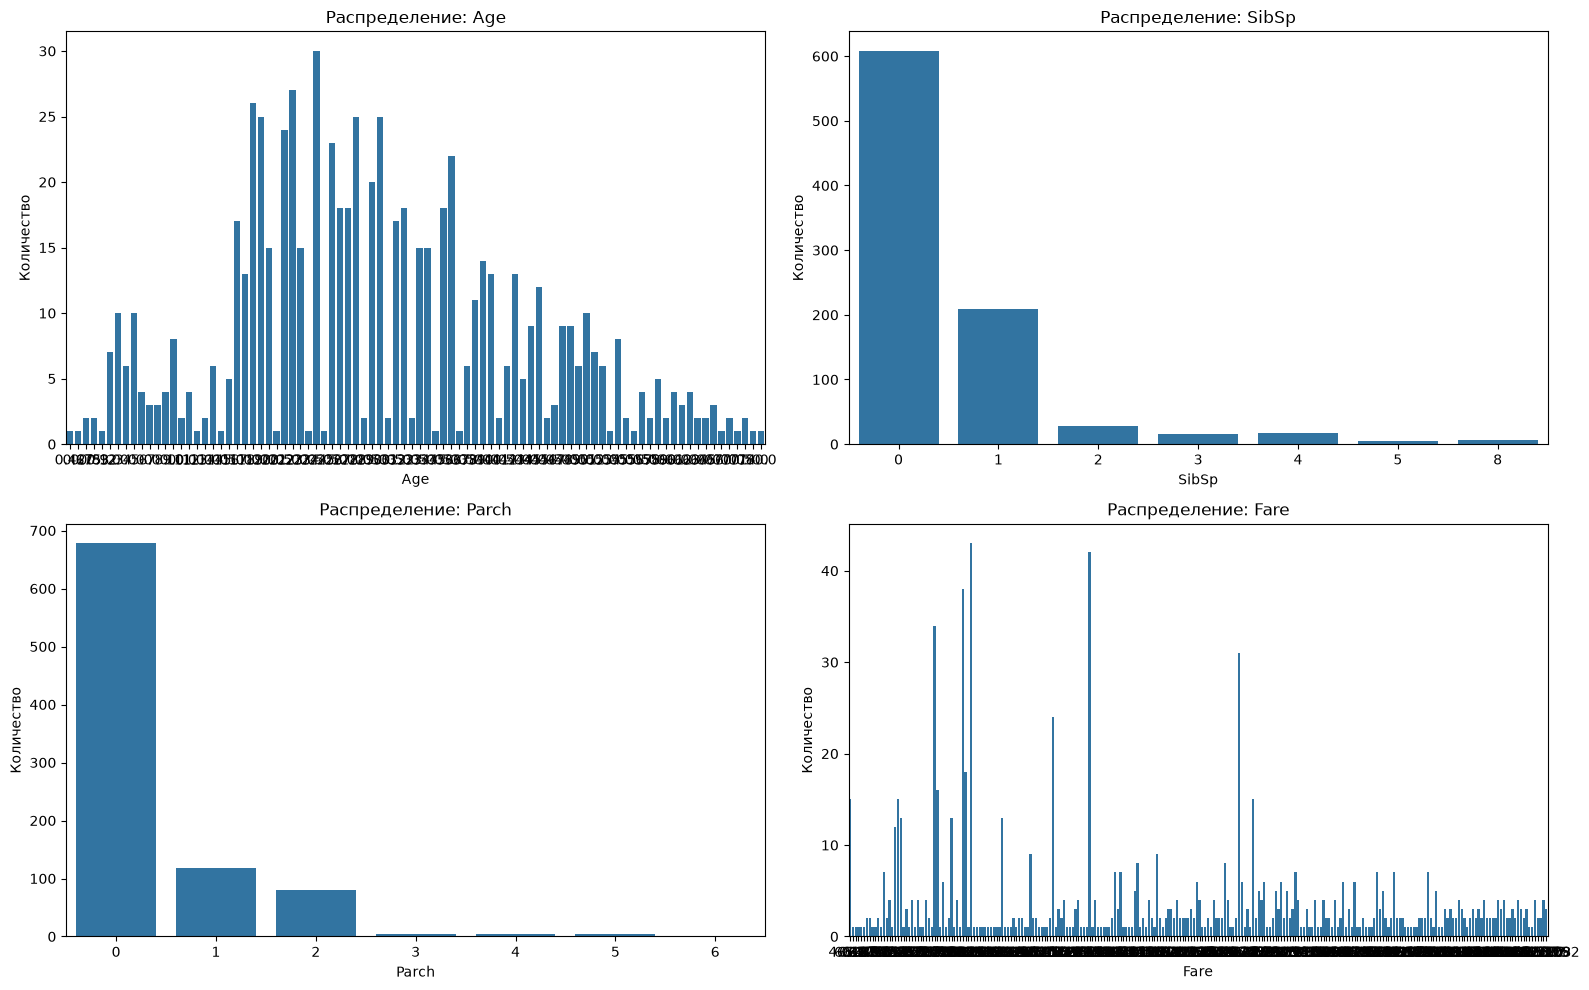

In [29]:
import numpy as np

# Числовые столбцы (исключая PassengerId и целевую переменную)
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['PassengerId', 'Survived', 'Pclass']]
len_num_cols = len(numeric_cols)
print('Числовые признаки:', numeric_cols, ', Количество: ', len_num_cols)


# Визуализация распределений числовых признаков
fig, axes = plt.subplots(2, len_num_cols//2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.countplot(x=col, data=df_train, ax=axes[i])
    axes[i].set_title(f'Распределение: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Количество')

plt.tight_layout()
plt.show()

## Correlation analysis

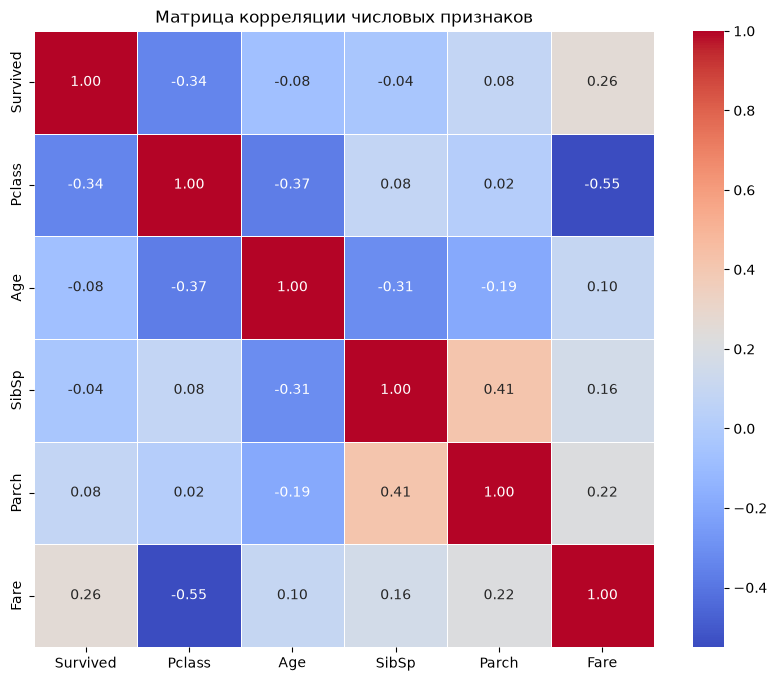

In [30]:
# Корреляция между числовыми признаками
corr_matrix = df_train[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляции числовых признаков')
plt.show()

## Teaching model

In [31]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

df_train = df_train.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId'], errors='ignore')

df_train['Age'] = df_train['Age'].fillna(df_train['Age'].median())
df_train['Fare'] = df_train['Fare'].fillna(df_train['Fare'].median())
df_train['Embarked'] = df_train['Embarked'].fillna(df_train['Embarked'].mode()[0])

df_train = pd.get_dummies(df_train, columns=['Sex', 'Embarked'], drop_first=True)

cols = [c for c in df_train.columns if c != 'Survived']

from sklearn.model_selection import train_test_split

X = df_train[cols]
y = df_train['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       
    random_state=42,    
    shuffle=True
)
model = LogisticRegression(max_iter=2000, C=2.0)
model.fit(X_train, y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",2.0
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [32]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8100558659217877
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

